In [1]:
import numpy as np

In [8]:
class LinearRegression :
    def __init__(self,learning_rate=0.01,n_iter=1000):
        self.bias=None
        self.weights=None
        self.lr=learning_rate
        self.n_iter=n_iter

    def fit(self,X,y): # X_train,y_train
        m,n=X.shape # ( no of samples,  no of features )

        # STEP 1 -->  Initilize
        self.bias=0
        self.weights=np.zeros(n) # [0,0,.....0]

        # Gradient Decent
        for i in range(self.n_iter):
            
             # STEP 2 --> calc  y_pred
            y_pred=self.bias + np.dot(X,self.weights)
    
            # STEP 3 -> calc gradient
            db=(1/m) * np.sum(y_pred-y)
            dw=(1/m) * np.dot(X.T,(y_pred-y))
    
            # STEP 4 --> convegence theorem - update parameter
            self.bias -=self.lr * db
            self.weights -=self.lr * dw

    def predict(self, X):
            y_pred=self.bias + np.dot(X,self.weights)
            return y_pred
    

In [9]:
X=np.array([[1],[2],[3],[4],[5]])
y=np.array([2,4,6,8,10])

model =LinearRegression()
model.fit(X,y)

y_pred=model.predict(X)
print(y_pred)

[2.06850809 4.04226297 6.01601785 7.98977273 9.96352761]


In [29]:
# Linear Regression with Ordinary Least Square OLS
class LinearRegressionOLS :
    def __init__(self):
        self.bias=None
        self.weights=None

    def fit(self,X,y):
        m,n=X.shape
        
        X_b=np.c_[np.ones((m,1)),X]
        
        # theta=np.dot(np.Linearlg.inv(np.dot(X_b.T,X_b)),np.dot(X_b.T,y))
        
        theta=np.linalg.inv( X_b.T @ X_b) @ X_b.T @ y
        
        self.bias=theta[0]
        self.weights=theta[1:]

    def predict(self,X):
        y_pred=self.bias + np.dot(X,self.weights)
        return y_pred

In [31]:
X=np.array([[1],[2],[3],[4],[5]])
y=np.array([2,4,6,8,10])

model =LinearRegressionOLS()
model.fit(X,y)

y_pred=model.predict(X)
print(y_pred)
print(model.bias)
print(model.weights)

[ 2.  4.  6.  8. 10.]
5.329070518200751e-15
[2.]


In [47]:
import numpy as np

class LogisticRegression:
    
    def __init__(self, learning_rate=0.1, n_iter=1000):
        self.bias = None
        self.weights = None
        self.lr = learning_rate
        self.n_iter = n_iter

    # Sigmoid function
    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    # Training
    def fit(self, X, y):
        m, n = X.shape
        
        self.bias = 0
        self.weights = np.zeros(n)

        for _ in range(self.n_iter):
            # Linear combination
            z = self.bias + np.dot(X, self.weights)
            
            # Sigmoid activation
            y_pred = self._sigmoid(z)

            # Gradients
            db = (1/m) * np.sum(y_pred - y)
            dw = (1/m) * np.dot(X.T, (y_pred - y))

            # Update
            self.bias -= self.lr * db
            self.weights -= self.lr * dw

    # Probability prediction
    def get_probabilities(self, X):
        z = self.bias + np.dot(X, self.weights)
        return self._sigmoid(z)

    # Class prediction
    def predict(self, X, threshold=0.5):
        probabilities = self.get_probabilities(X)
        return (probabilities >= threshold).astype(int)


In [49]:
X=np.array([[1,2],[2,3],[3,4],[4,5]])
y=np.array([0,0,1,1])

model =LogisticRegression()
model.fit(X,y)

y_pred=model.predict(X)
print(y_pred)
print(model.get_probabilities(X))

[0 0 1 1]
[0.02871674 0.26532955 0.81521201 0.98178143]


In [53]:
import numpy as np
from collections import Counter

class KNN:
    
    def __init__(self, k=3):
        self.k = k
    
    # Store training data
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    
    # Euclidean distance
    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))
    
    # Predict single sample
    def _predict(self, x):
        # Compute distances to all training samples
        distances = [self._euclidean_distance(x, x_train) 
                     for x_train in self.X_train]
        
        # Get indices of k nearest neighbors
        k_indices = np.argsort(distances)[:self.k]
        
        # Get labels of k nearest neighbors
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        
        # Majority vote
        most_common = Counter(k_nearest_labels).most_common(1)
        
        return most_common[0][0]
    
    # Predict multiple samples
    def predict(self, X):
        return np.array([self._predict(x) for x in X])


In [55]:
X_train = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [6, 5],
    [7, 7]
])

y_train = np.array([0, 0, 0, 1, 1])

X_test = np.array([
    [2, 2],
    [6, 6]
])
# Train model
model = KNN(k=3)
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

print("Predictions of KNN:", predictions)

Predictions of KNN: [0 1]


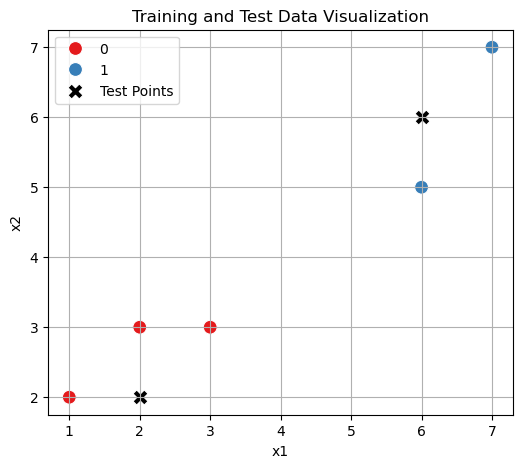

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


X_train_df = pd.DataFrame(X_train, columns=["x1", "x2"])
X_train_df["label"] = y_train

X_test_df = pd.DataFrame(X_test, columns=["x1", "x2"])

plt.figure(figsize=(6, 5))

# Training data
sns.scatterplot(
    data=X_train_df,
    x="x1",
    y="x2",
    hue="label",
    palette="Set1",
    s=100
)

# Test data
sns.scatterplot(
    data=X_test_df,
    x="x1",
    y="x2",
    color="black",
    marker="X",
    s=120,
    label="Test Points"
)

plt.title("Training and Test Data Visualization")
plt.legend()
plt.grid(True)
plt.show()
   